In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

In [ ]:
!ls

drive	     spark-3.1.1-bin-hadoop3.2	    spark-3.1.1-bin-hadoop3.2.tgz.1
sample_data  spark-3.1.1-bin-hadoop3.2.tgz


In [ ]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
path_file = '/content/drive/MyDrive/Colab Notebooks/Data Science and AI/Novena sesión/Monterrey Pollution Data 2.csv'

In [ ]:
df_weather = spark.read.csv(path_file, header = True, sep = ",", inferSchema = True)
df_weather.show(5)

+---------+-----+---+-------+-------+----+----+----+----+----+---+----+-----+-----+-----+---+-----+----+---+---+
|     Date|Month|Day|DayWeek|WeekDay|Hour|  CO|  NO| NO2| NOX| O3|PM10|PM2.5|  PRS|RAINF| RH|   SR|TOUT|WSR|WDV|
+---------+-----+---+-------+-------+----+----+----+----+----+---+----+-----+-----+-----+---+-----+----+---+---+
|01-ene-15|    1|  1|    jue|      5|   1|2.51|10.2|12.9|23.1| 10| 139|   80|725.4| 0.01| 96|  0.0|3.91|7.2|344|
|01-ene-15|    1|  1|    jue|      5|   2|2.41| 9.2|11.6|20.8|  7|  42|   29|725.0| 0.02| 96|  0.0|3.81|6.3|341|
|01-ene-15|    1|  1|    jue|      5|   3|2.39| 8.1|11.8|19.9|  7|  23|    9|724.4|  0.0| 96|  0.0|3.85|5.2|346|
|01-ene-15|    1|  1|    jue|      5|   5|2.26| 5.3| 8.9|14.2|  7|  23|   14|724.0| 0.01| 96|  0.0|3.79|5.6|336|
|01-ene-15|    1|  1|    jue|      5|   8|2.25| 7.2|10.2|17.4|  5|  15|    8|724.3|  0.0| 96|0.023|3.93|4.8|354|
+---------+-----+---+-------+-------+----+----+----+----+----+---+----+-----+-----+-----+---+---

In [ ]:
print("Número de registros: " + str(df_weather.count()))
print("Número de columnas: " + str(len(df_weather.columns)))

Número de registros: 3859
Número de columnas: 20


In [ ]:
df_weather.describe().toPandas().T

,0,1,2,3,4
summary,count,mean,stddev,min,max
Date,3859,None,None,01-abr-15,31/08/2015
Month,3859,4.820678932365898,2.8352877939176295,1,11
Day,3859,15.76444674786214,9.157213402989008,1,31
DayWeek,3859,None,None,dom,vie
WeekDay,3859,4.075926405804613,1.9730397456778965,1,7
Hour,3859,12.037833635656906,6.869487540512553,0,23
CO,3859,1.8006219227779212,0.8720340991225567,0.29,8.56
NO,3859,13.503653796320318,26.856244699079294,2.3,414.3
NO2,3859,17.539284788381988,13.301006799154928,0.4,99.2


In [ ]:
df_weather.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- DayWeek: string (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOX: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM2.5: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RAINF: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
# Renombramos la columna PM2.5 a PM25
df_weather = df_weather.withColumnRenamed('PM2.5', 'PM25')

In [ ]:
# Eliminamos las variables Date y WeekDay ya que son variables tipo string, además de que nos proporcionan información que ya encontramos mejor representada en otras 3 variables
df_weather_features = df_weather.drop('Date', 'DayWeek')

# Eliminamos registros con valores nulos
df_weather_features_clean = df_weather_features.dropna()
df_weather_features_clean = df_weather_features_clean.na.drop()

# Eliminamos registros duplicados
df_weather_features_clean = df_weather_features_clean.dropDuplicates()

In [ ]:
df_weather_features_clean.describe().toPandas().T

,0,1,2,3,4
summary,count,mean,stddev,min,max
Month,3859,4.820678932365898,2.8352877939176317,1,11
Day,3859,15.76444674786214,9.157213402989003,1,31
WeekDay,3859,4.075926405804613,1.9730397456778948,1,7
Hour,3859,12.037833635656906,6.869487540512549,0,23
CO,3859,1.8006219227779217,0.8720340991225551,0.29,8.56
NO,3859,13.503653796320288,26.85624469907931,2.3,414.3
NO2,3859,17.53928478838196,13.30100679915493,0.4,99.2
NOX,3859,30.973257321216394,36.09049803938844,3.1,436.0
O3,3859,22.658719875615443,16.510561318859267,2,92


# **Gráficos**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

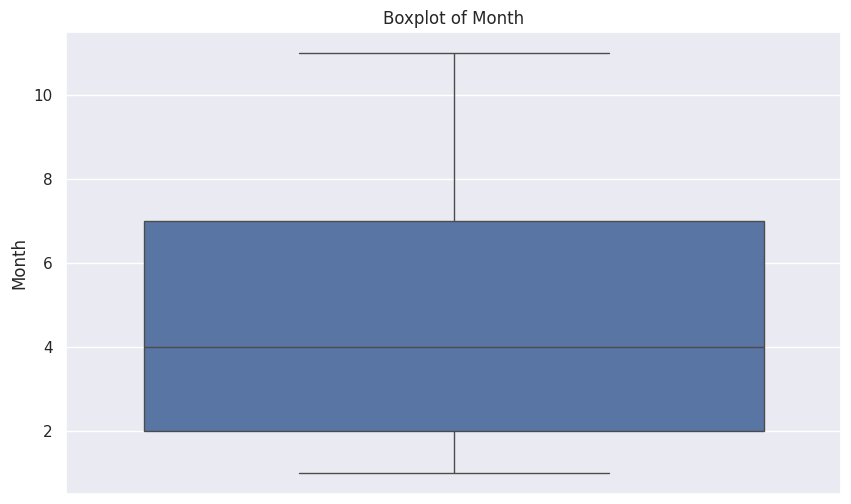

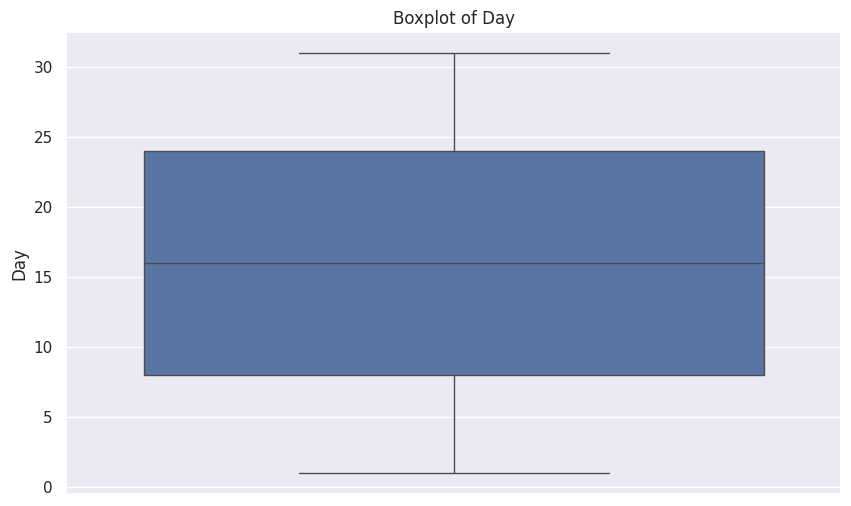

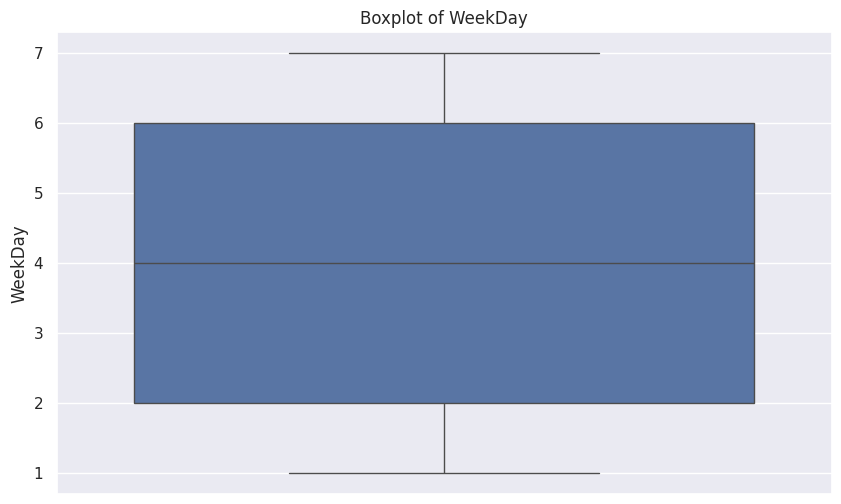

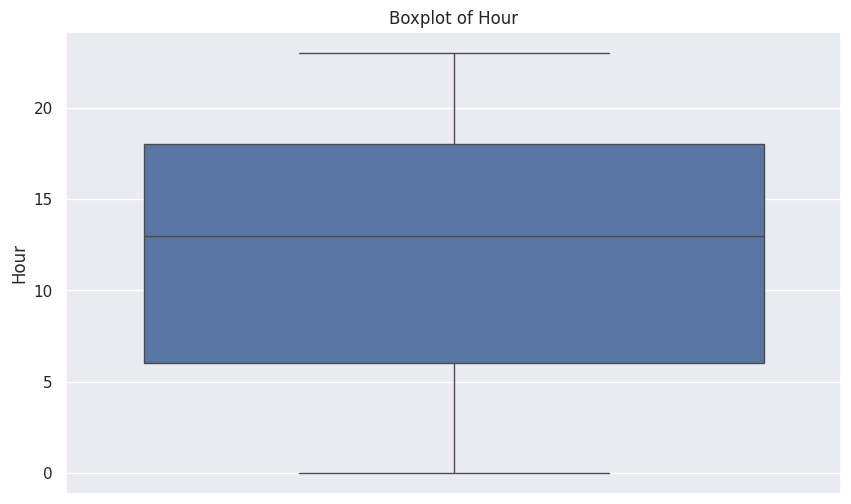

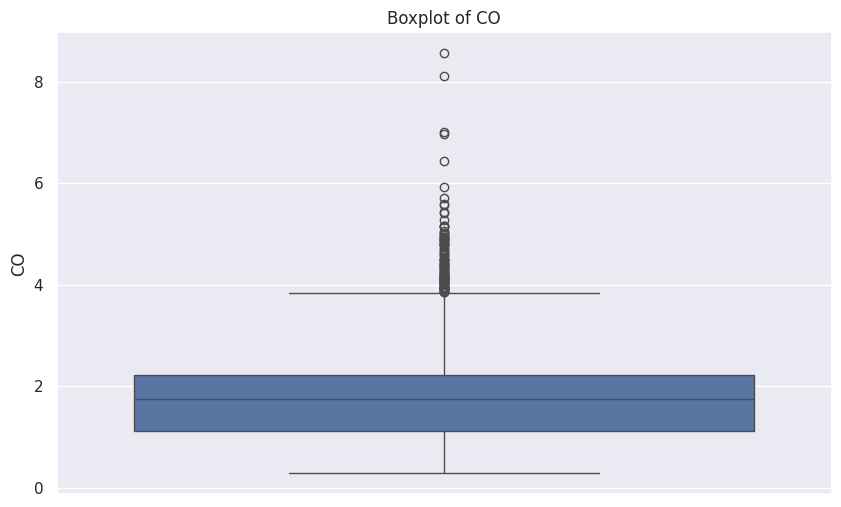

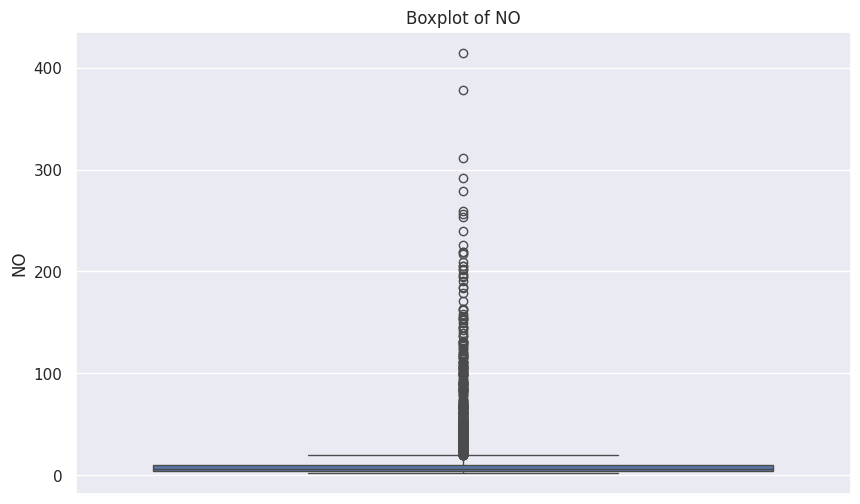

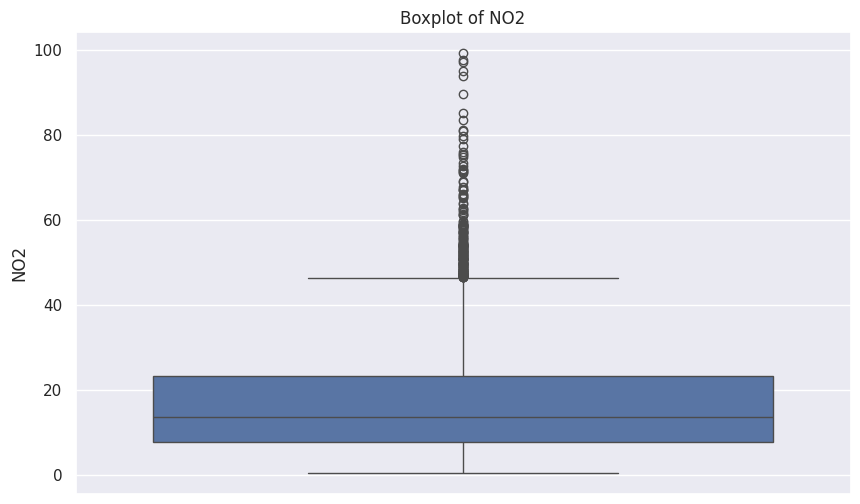

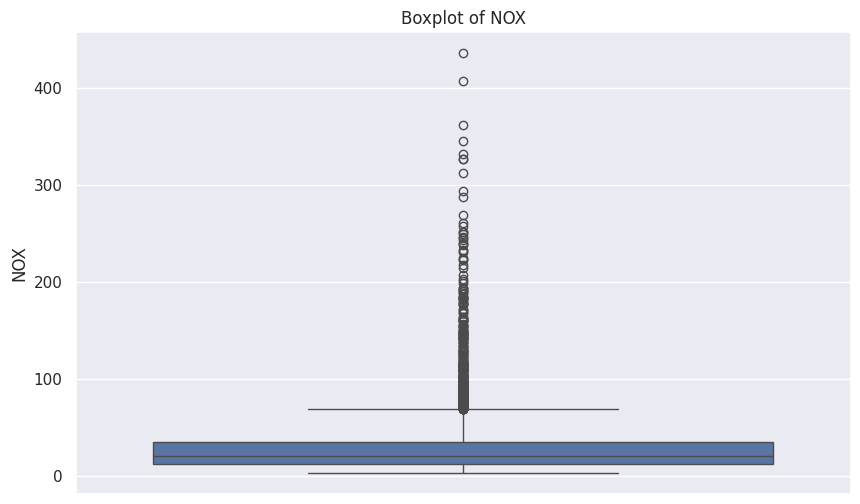

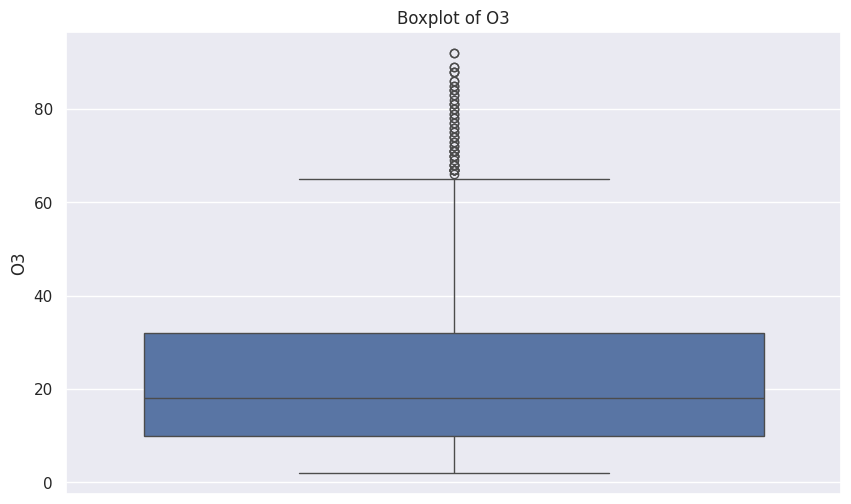

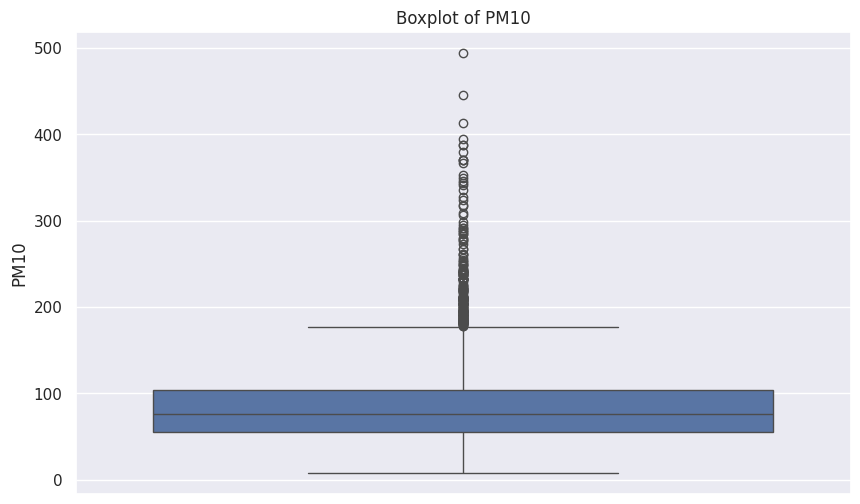

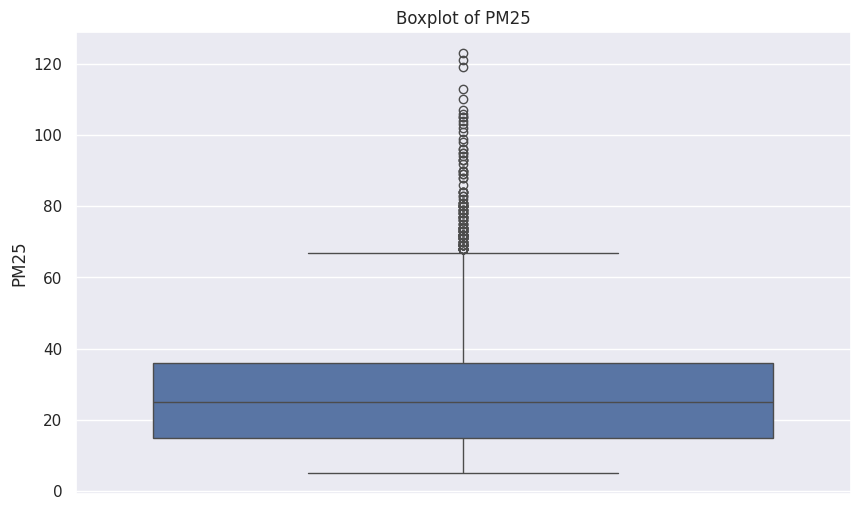

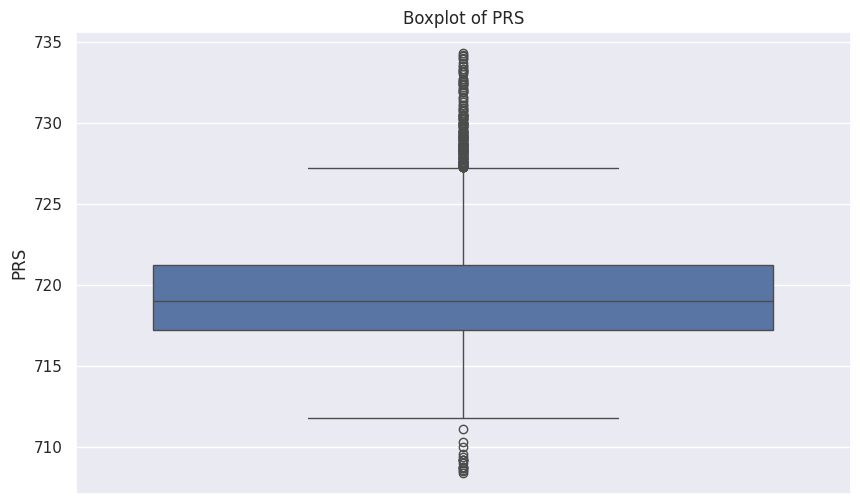

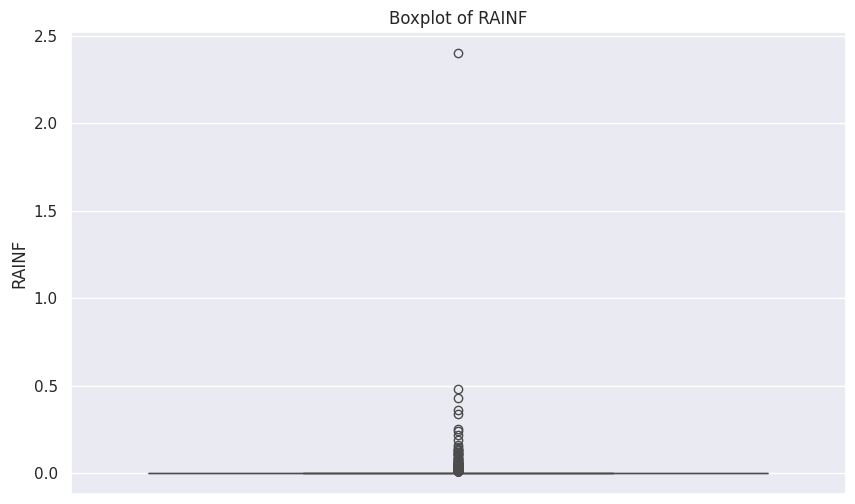

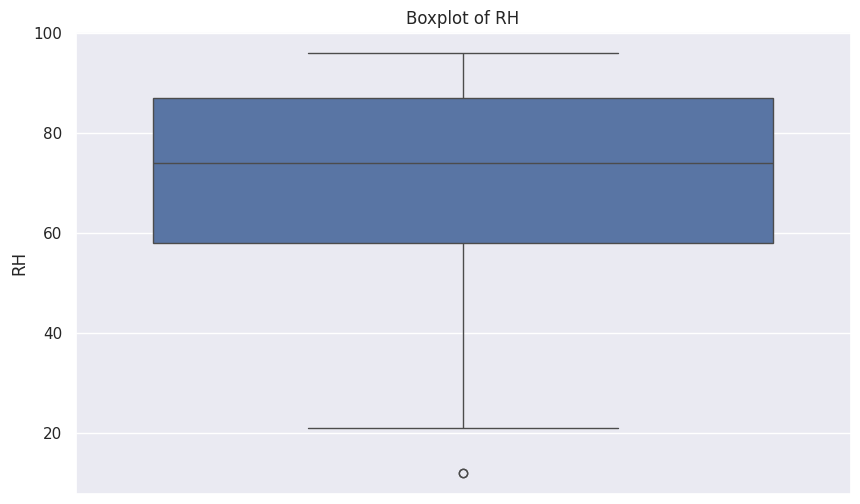

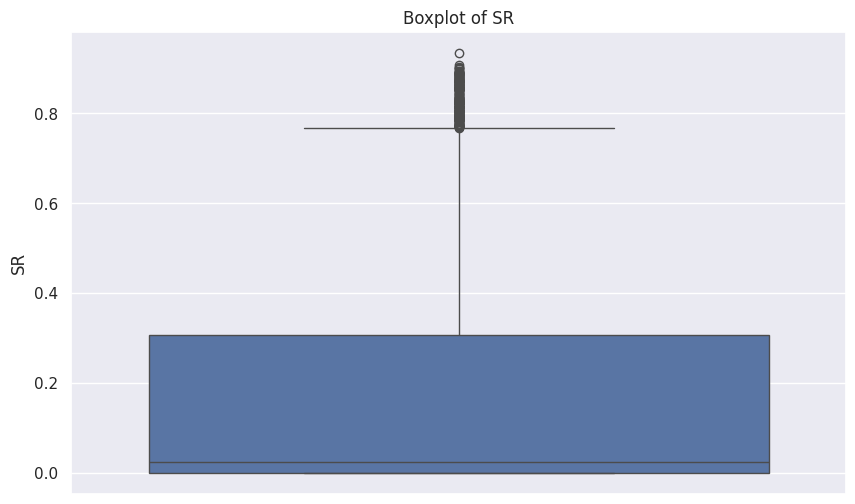

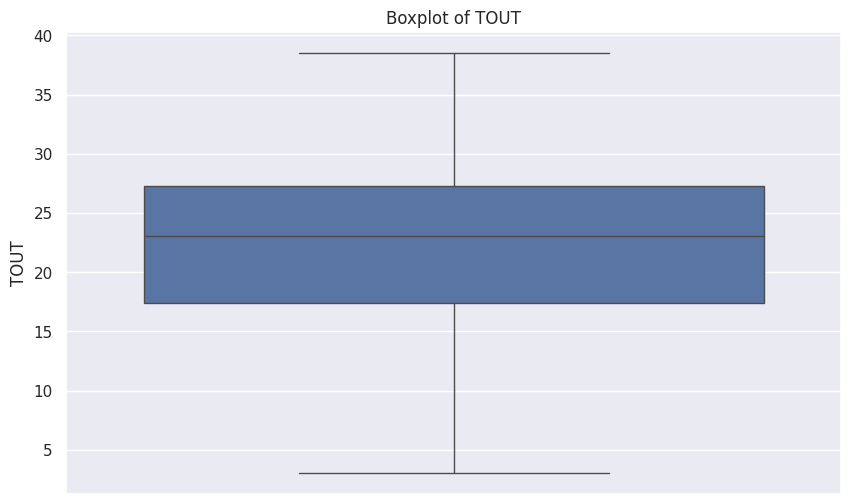

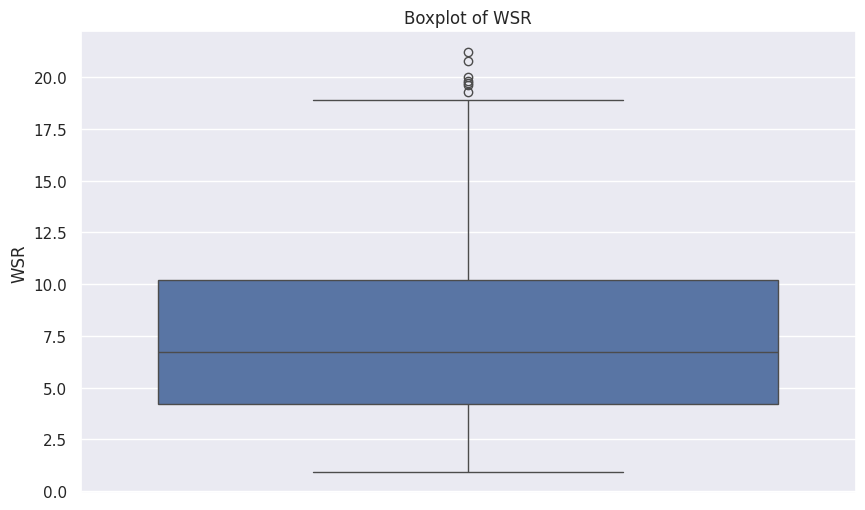

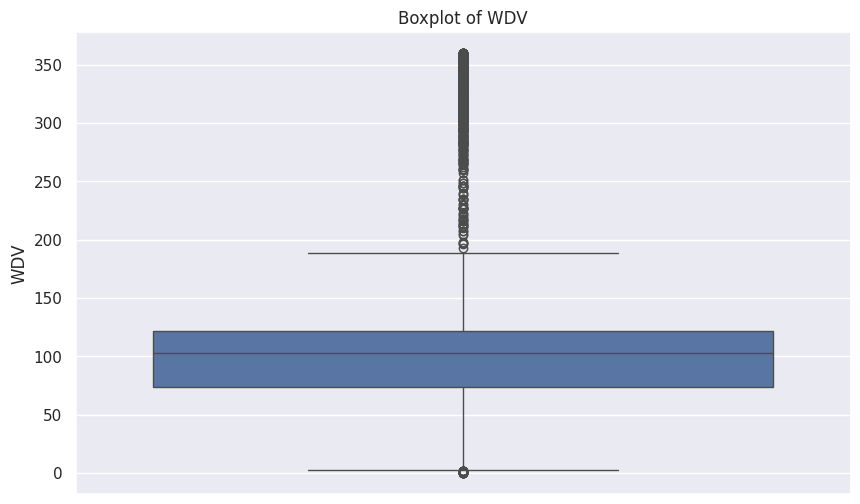

In [ ]:
df_pandas = df_weather_features_clean.toPandas()

for col in df_pandas:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df_pandas[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

Después de revisar cada gráfico de caja para cada una de las variables, podemos notar que en la mayoría existen outliers, lo cual nos indica como la contaminación aumentó muchísimo más de la media, por lo que debemos de manejar esta información considerando estos outliers, ya que son los que nos ayudarán a entender como las variables se relacionan para que la ciudad esté más contaminada.

<Axes: xlabel='O3', ylabel='PM25'>

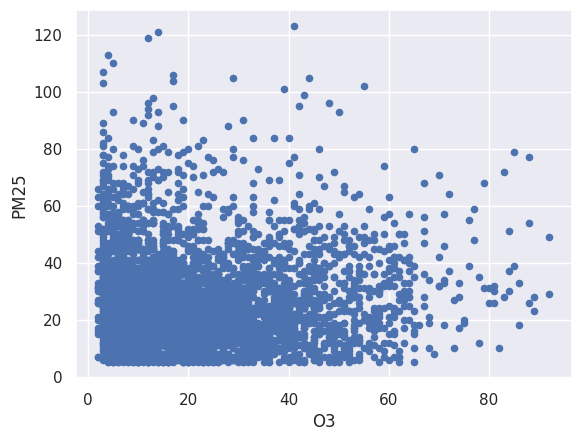

In [ ]:
# Realizamos un gráfico de dispersión
df_weather_features_clean.select('PM25', 'O3').toPandas().plot.scatter(x = 'O3', y = 'PM25')

# **Normalizacíon**

Debido a que tenemos muchos outliers en los datos no es muy recomendable usar Min-max para escalar los datos debido a que se genera un sesgo. Por lo tanto podríamos usar z-score o alguna otra normalización como un robust scaler.

In [ ]:
from pyspark.sql.functions import mean, stddev, col
from pyspark.sql import DataFrame

normalized_cols = []
for col_name in df_weather_features_clean.columns:
    mean_value = df_weather_features_clean.agg(mean(col(col_name))).first()[0]
    std_value = df_weather_features_clean.agg(stddev(col(col_name))).first()[0]

    if std_value is not None and std_value != 0:
        normalized_col = ((col(col_name) - mean_value) / std_value).alias(col_name)
        normalized_cols.append(normalized_col)
    else:

        normalized_cols.append(col(col_name))

df_weather_features_clean_norm_Zscore = df_weather_features_clean.select(normalized_cols)

df_weather_features_clean_norm_Zscore.describe().show()

+-------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|summary|               Month|                 Day|             WeekDay|                Hour|                  CO|                 NO|                 NO2|                 NOX|                  O3|                PM10|                PM25|                 PRS|               RAINF|                  RH|                  SR|                TOUT|                 WSR|                 WDV|
+-------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------

In [225]:
from pyspark.ml.feature import RFormula
rForm = RFormula(formula="O3 ~ .")
fittedRF = rForm.fit(df_weather_features_clean_norm_Zscore)
preparedDF_a = fittedRF.transform(df_weather_features_clean_norm_Zscore)
preparedDF_a.show(5)

+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+--------------------+-------------------+
|           Month|                Day|            WeekDay|               Hour|                CO|                  NO|                 NO2|                 NOX|                 O3|               PM10|               PM25|               PRS|               RAINF|                RH|                 SR|               TOUT|                 WSR|               WDV|            features|              label|
+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+-------------------+------------------

In [226]:
from pyspark.ml.feature import RFormula
rForm = RFormula(formula="O3 ~ .")
fittedRF = rForm.fit(df_weather_features_clean)
df_pollution_features_clean_ax = fittedRF.transform(df_weather_features_clean)
df_pollution_features_clean_ax.show(5)

+-----+---+-------+----+----+----+----+----+---+----+----+-----+-----+---+-----+----+---+---+--------------------+-----+
|Month|Day|WeekDay|Hour|  CO|  NO| NO2| NOX| O3|PM10|PM25|  PRS|RAINF| RH|   SR|TOUT|WSR|WDV|            features|label|
+-----+---+-------+----+----+----+----+----+---+----+----+-----+-----+---+-----+----+---+---+--------------------+-----+
|    1|  1|      5|   1|2.51|10.2|12.9|23.1| 10| 139|  80|725.4| 0.01| 96|  0.0|3.91|7.2|344|[1.0,1.0,5.0,1.0,...| 10.0|
|    1|  1|      5|   2|2.41| 9.2|11.6|20.8|  7|  42|  29|725.0| 0.02| 96|  0.0|3.81|6.3|341|[1.0,1.0,5.0,2.0,...|  7.0|
|    1|  1|      5|   3|2.39| 8.1|11.8|19.9|  7|  23|   9|724.4|  0.0| 96|  0.0|3.85|5.2|346|[1.0,1.0,5.0,3.0,...|  7.0|
|    1|  1|      5|   5|2.26| 5.3| 8.9|14.2|  7|  23|  14|724.0| 0.01| 96|  0.0|3.79|5.6|336|[1.0,1.0,5.0,5.0,...|  7.0|
|    1|  1|      5|   8|2.25| 7.2|10.2|17.4|  5|  15|   8|724.3|  0.0| 96|0.023|3.93|4.8|354|[1.0,1.0,5.0,8.0,...|  5.0|
+-----+---+-------+----+----+---

# **Correlaciones**

In [ ]:
from pyspark.ml.stat import Correlation

from pyspark.ml.feature import VectorAssembler

In [ ]:
df_weather_features_clean.printSchema()

root
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOX: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM25: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RAINF: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [229]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=['CO', 'NO', 'NO2', 'NOX', 'PM10', 'PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDV', 'O3', 'PM25'], outputCol = 'features')
preparedDF_b = assembler.transform(df_weather_features_clean_norm_Zscore)

preparedDF_b.show(5)

+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+--------------------+
|           Month|                Day|            WeekDay|               Hour|                CO|                  NO|                 NO2|                 NOX|                 O3|               PM10|               PM25|               PRS|               RAINF|                RH|                 SR|               TOUT|                 WSR|               WDV|            features|
+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+------------------

In [230]:
df_vector.select(vector_col).show(10, truncate=False)

+----------------------------------------------------------------------------------------+
|corr_features                                                                           |
+----------------------------------------------------------------------------------------+
|[1.0,1.0,5.0,1.0,2.51,10.2,12.9,23.1,10.0,139.0,80.0,725.4,0.01,96.0,0.0,3.91,7.2,344.0]|
|[1.0,1.0,5.0,2.0,2.41,9.2,11.6,20.8,7.0,42.0,29.0,725.0,0.02,96.0,0.0,3.81,6.3,341.0]   |
|[1.0,1.0,5.0,3.0,2.39,8.1,11.8,19.9,7.0,23.0,9.0,724.4,0.0,96.0,0.0,3.85,5.2,346.0]     |
|[1.0,1.0,5.0,5.0,2.26,5.3,8.9,14.2,7.0,23.0,14.0,724.0,0.01,96.0,0.0,3.79,5.6,336.0]    |
|[1.0,1.0,5.0,8.0,2.25,7.2,10.2,17.4,5.0,15.0,8.0,724.3,0.0,96.0,0.023,3.93,4.8,354.0]   |
|[1.0,1.0,5.0,9.0,2.21,5.8,8.2,14.0,7.0,16.0,6.0,724.3,0.0,96.0,0.052,4.13,4.2,15.0]     |
|[1.0,1.0,5.0,12.0,2.38,10.0,10.1,20.1,10.0,22.0,17.0,722.6,0.0,96.0,0.127,6.6,3.2,29.0] |
|[1.0,1.0,5.0,13.0,2.51,11.5,12.3,23.8,12.0,32.0,16.0,721.7,0.0,95.0,0.15,6.89,4.8,2.0]  |

In [231]:
corr_pearson_1 = Correlation.corr(df_vector, vector_col, method = 'pearson')
print("Pearson Corr Matrix\n",corr_pearson_1.collect()[0]["pearson({})".format(vector_col)].values)

Pearson Corr Matrix
 [ 1.         -0.06681874  0.00577055  0.0054055  -0.54861099 -0.31319863
 -0.59194504 -0.45351715  0.21388996 -0.23988475 -0.05753043 -0.43358683
 -0.0108237  -0.18114563  0.1609054   0.67349906  0.26464103 -0.22102167
 -0.06681874  1.         -0.00598214 -0.00155594  0.10161249  0.03817932
  0.05592515  0.04917678  0.0894571   0.07758294 -0.0136505  -0.03661393
 -0.02347321 -0.2098234   0.06236327  0.11085136  0.04526884  0.0283507
  0.00577055 -0.00598214  1.         -0.00860741  0.03326163 -0.03619181
 -0.02281854 -0.03533288  0.01599319 -0.01817025  0.01675521  0.06762479
  0.03130008  0.0775407  -0.0104502  -0.06985465  0.0251707  -0.04951724
  0.0054055  -0.00155594 -0.00860741  1.          0.06385422 -0.06897343
  0.06570135 -0.02702815  0.2283809   0.08895805  0.09788411 -0.04785694
  0.0207946  -0.36251786  0.04857046  0.21874229  0.42407231 -0.12821527
 -0.54861099  0.10161249  0.03326163  0.06385422  1.          0.5978396
  0.67806613  0.69620186 -0.1964

In [ ]:
corr_spearman_1 = Correlation.corr(df_vector, vector_col, method='spearman')
print("Spearman Corr Matrix\n",corr_spearman_1.collect()[0]["spearman({})".format(vector_col)].values)

Spearman Corr Matrix
 [ 1.00000000e+00 -6.91158246e-02  1.41402764e-03  5.61378594e-04
 -5.68964967e-01 -5.96012289e-01 -6.89099554e-01 -6.96122375e-01
  2.43576471e-01 -1.88967171e-01  7.08157171e-03 -4.41821163e-01
 -9.74134445e-02 -1.86296424e-01  1.20081969e-01  7.15890721e-01
  2.95830644e-01 -2.26584124e-01 -6.91158246e-02  1.00000000e+00
 -7.11282777e-03 -2.40621779e-03  4.38405184e-02 -2.50506608e-02
  2.71781947e-02  6.92183670e-03  7.77856075e-02  7.97787105e-02
 -9.45712415e-03  4.99919747e-02 -9.22869292e-02 -2.00340952e-01
  5.49846906e-02  8.82070941e-02  3.78560690e-02  8.42499162e-03
  1.41402764e-03 -7.11282777e-03  1.00000000e+00 -9.70853565e-03
  4.85368401e-02  1.87059346e-02 -4.29746751e-03  1.16250229e-02
  8.38482384e-03 -1.54688581e-02  1.48033583e-03  6.09709264e-02
  3.50023384e-02  7.05306424e-02 -1.73617636e-03 -5.18106134e-02
  1.90487515e-02 -4.18943779e-02  5.61378594e-04 -2.40621779e-03
 -9.70853565e-03  1.00000000e+00  8.32254749e-02  1.53087172e-01
  8

In [ ]:
import plotly.express as px
import numpy as np

vector_col = "corr_features"

pearson_corr_arr = np.matrix(corr_pearson_1.collect()[0]["pearson({})".format(vector_col)].values).reshape(len(df_weather_features_clean.columns), len(df_weather_features_clean.columns))
fig = px.imshow(pearson_corr_arr)
fig.show()

[Text(0.5, 0, 'Month'),
 Text(1.5, 0, 'Day'),
 Text(2.5, 0, 'WeekDay'),
 Text(3.5, 0, 'Hour'),
 Text(4.5, 0, 'CO'),
 Text(5.5, 0, 'NO'),
 Text(6.5, 0, 'NO2'),
 Text(7.5, 0, 'NOX'),
 Text(8.5, 0, 'O3'),
 Text(9.5, 0, 'PM10'),
 Text(10.5, 0, 'PM25'),
 Text(11.5, 0, 'PRS'),
 Text(12.5, 0, 'RAINF'),
 Text(13.5, 0, 'RH'),
 Text(14.5, 0, 'SR'),
 Text(15.5, 0, 'TOUT'),
 Text(16.5, 0, 'WSR'),
 Text(17.5, 0, 'WDV')]

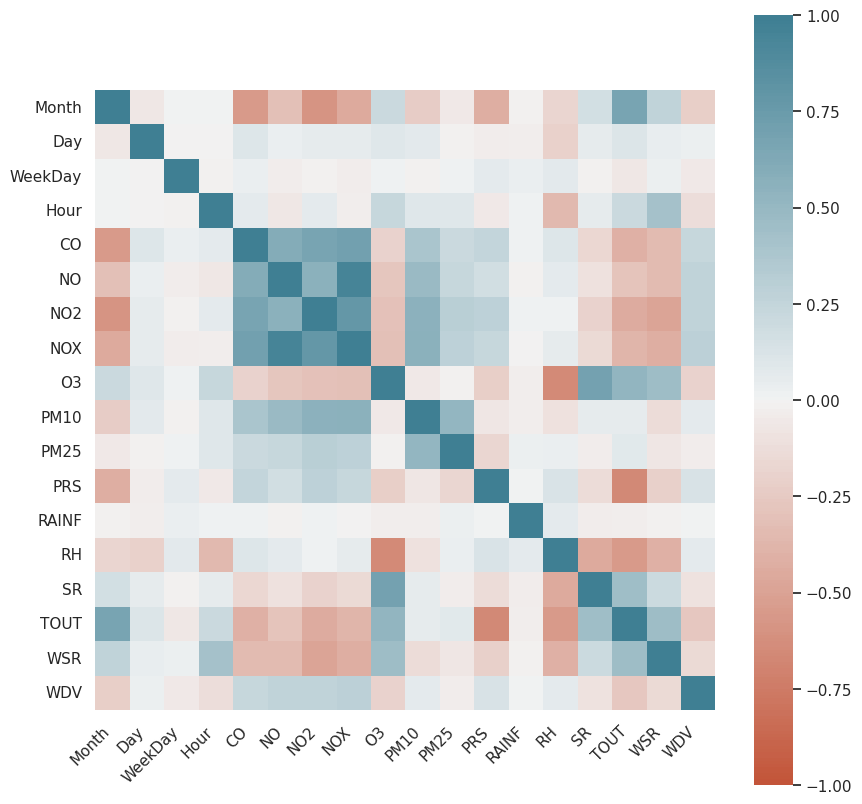

In [ ]:
import pandas as pd

df_columns2 = df_weather_features_clean.columns

sns.set(color_codes=True, font_scale=1.0)
#Establecer el tamaño de la figura
plt.figure(figsize=(10,10))

# Note que data debe estar en formato matriz de numpy
pearson_corr_df = pd.DataFrame(data=pearson_corr_arr, index=df_columns2,columns=df_columns2)

ax = sns.heatmap(
    pearson_corr_df,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)

#La barra de anotación
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)

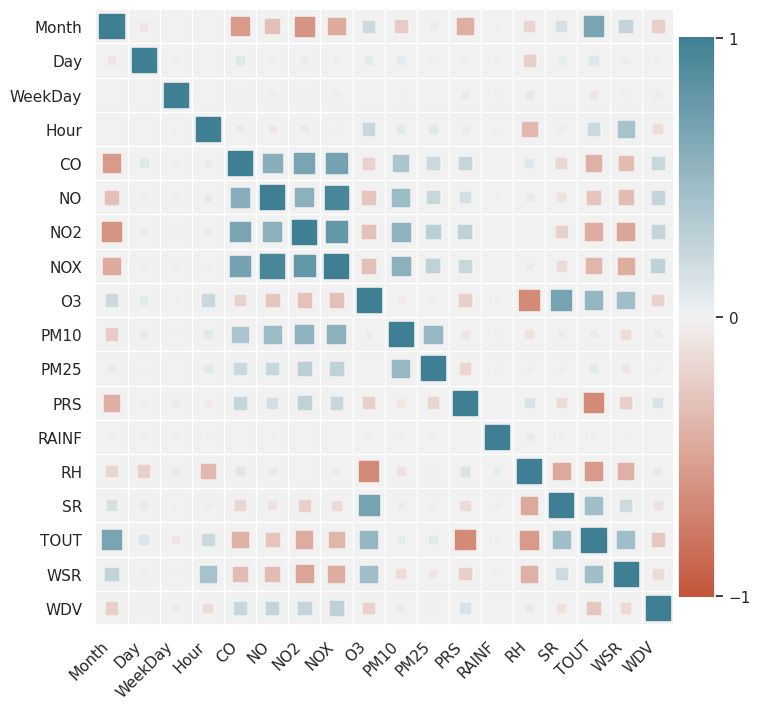

In [ ]:
!pip install heatmapz
from heatmap import corrplot

plt.figure(figsize=(8, 8))
# Aquí se puede pasar directamente un Spark Dataframe
corrplot(pearson_corr_df ,size_scale=300)

In [ ]:
from pyspark.ml.feature import RFormula
rForm = RFormula(formula="Origin ~ .")
fittedRF = rForm.fit(df_weather_features_clean_norm_Zscore)
preparedDF_a = fittedRF.transform(df_weather_features_clean_norm_Zscore)
preparedDF_a.show(5)

+-------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|              Month|                Day|             WeekDay|               Hour|                 CO|                  NO|                 NO2|                 NOX|                 O3|                PM10|                PM25|                PRS|               RAINF|                 RH|                 SR|                TOUT|                 WSR|                 WDV|            features|
+-------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------

In [ ]:
from pyspark.ml.feature import VectorAssembler
# from pyspark.ml.feature import StringIndexer # Removed as 'Origin' column does not exist

# Se genera el vector de features
assembler = VectorAssembler(inputCols=['CO', 'NO', 'NO2', 'NOX', 'PM10', 'PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDV', 'O3', 'PM25'], outputCol = 'features')
preparedDF_b = assembler.transform(df_weather_features_clean_norm_Zscore)

# Se añade una nueva columna transformando la variable objetivo a una columna númerica
# Assuming "Origin" is the target variable to be indexed. If not, please specify the correct column name.
# If there is no categorical target variable to be indexed, this part might be unnecessary.
# indexer = StringIndexer(inputCol="Origin", outputCol="label")
# preparedDF_b = indexer.fit(preparedDF_b).transform(preparedDF_b)

preparedDF_b.show(5)

+-------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|              Month|                Day|             WeekDay|               Hour|                 CO|                  NO|                 NO2|                 NOX|                 O3|                PM10|                PM25|                PRS|               RAINF|                 RH|                 SR|                TOUT|                 WSR|                 WDV|            features|
+-------------------+-------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------

In [232]:
preparedDF_a.explain()
preparedDF_b.explain()

== Physical Plan ==
*(2) Project [Month#179754, Day#180071, WeekDay#180307, Hour#180812, CO#181022, NO#181488, NO2#181826, NOX#182046, O3#182551, PM10#182777, PM25#183187, PRS#183502, RAINF#183760, RH#184231, SR#184532, TOUT#184647, WSR#185150, WDV#185467, features#4337885, O3#182551 AS label#4337944]
+- *(2) HashAggregate(keys=[WeekDay#20, WSR#34, PRS#29, RAINF#30, Month#17, NO2#24, TOUT#33, NO#23, Day#18, NOX#25, CO#22, RH#31, PM25#1442, WDV#35, O3#26, Hour#21, PM10#27, SR#32], functions=[])
   +- Exchange hashpartitioning(WeekDay#20, WSR#34, PRS#29, RAINF#30, Month#17, NO2#24, TOUT#33, NO#23, Day#18, NOX#25, CO#22, RH#31, PM25#1442, WDV#35, O3#26, Hour#21, PM10#27, SR#32, 1), ENSURE_REQUIREMENTS, [id=#2095888]
      +- *(1) HashAggregate(keys=[WeekDay#20, knownfloatingpointnormalized(normalizenanandzero(WSR#34)) AS WSR#34, knownfloatingpointnormalized(normalizenanandzero(PRS#29)) AS PRS#29, knownfloatingpointnormalized(normalizenanandzero(RAINF#30)) AS RAINF#30, Month#17, knownfloat

In [233]:
print("Número de registros: " + str(preparedDF_a.count()))

Número de registros: 3859


Muestreo aleatorio simple

In [234]:
# Construcción de un train - test con 200 ejecutores por default
spark.conf.set("spark.sql.shuffle.partitions", "200")
train_data_rand_200w_a,test_data_rand_200w_a = preparedDF_a.randomSplit([0.7,0.3], seed = 42)
print(f"""Existen {train_data_rand_200w_a.count()} instancias en el conjunto train, y {test_data_rand_200w_a.count()} en el conjunto test""")

Existen 2672 instancias en el conjunto train, y 1187 en el conjunto test


In [235]:
spark.conf.set("spark.sql.shuffle.partitions", "1")
train_data_rand_1w_a,test_data_rand_1w_a = preparedDF_a.randomSplit([0.7,0.3], seed = 42)
print(f"""Existen {train_data_rand_1w_a.count()} instancias en el conjunto train, y {test_data_rand_1w_a.count()} en el conjunto test""")

Existen 2756 instancias en el conjunto train, y 1103 en el conjunto test


**Muestreo a partir de variables O3 y PM2.5**

In [236]:
from pyspark.sql.functions import concat, lit
preparedDF_a_stratum = preparedDF_a.withColumn("stratum", concat(preparedDF_a["O3"], lit("_"), preparedDF_a["PM25"]))
preparedDF_a_stratum.show(5)


+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+--------------------+-------------------+--------------------+
|           Month|                Day|            WeekDay|               Hour|                CO|                  NO|                 NO2|                 NOX|                 O3|               PM10|               PM25|               PRS|               RAINF|                RH|                 SR|               TOUT|                 WSR|               WDV|            features|              label|             stratum|
+----------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+-----------------

In [237]:
preparedDF_a_stratum.printSchema()

root
 |-- Month: double (nullable = true)
 |-- Day: double (nullable = true)
 |-- WeekDay: double (nullable = true)
 |-- Hour: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOX: double (nullable = true)
 |-- O3: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- PM25: double (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RAINF: double (nullable = true)
 |-- RH: double (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- label: double (nullable = true)
 |-- stratum: string (nullable = true)



In [238]:
stratum_counts_O3 = preparedDF_a_stratum.groupBy("O3").count().collect()
stratum_counts_PM25 = preparedDF_a_stratum.groupBy("PM25").count().collect()
stratum_counts_combined_a = preparedDF_a_stratum.groupBy("O3", "PM25").count().collect()
stratum_counts_combined = preparedDF_a_stratum.groupBy("stratum").count().collect()

print(stratum_counts_O3)
print(stratum_counts_PM25)
print(stratum_counts_combined_a)
print(stratum_counts_combined)

[Row(O3=-0.7667043918825437, count=151), Row(O3=-0.948406269975158, count=115), Row(O3=-1.0695408553702341, count=144), Row(O3=-0.6455698064874675, count=117), Row(O3=-0.5244352210923913, count=97), Row(O3=-0.7061370991850056, count=117), Row(O3=-0.88783897727762, count=108), Row(O3=-1.0089735626726961, count=145), Row(O3=-1.1301081480677724, count=130), Row(O3=-0.5850025137899294, count=119), Row(O3=-0.8272716845800818, count=133), Row(O3=0.4446414620682184, count=67), Row(O3=0.5052087547657566, count=66), Row(O3=0.202372291278066, count=55), Row(O3=0.1418049985805279, count=65), Row(O3=-0.3427333429997769, count=92), Row(O3=0.5657760474632947, count=59), Row(O3=0.26293958397560413, count=57), Row(O3=0.020670413185451684, count=75), Row(O3=-0.40330063569731506, count=102), Row(O3=-0.22159875760470074, count=106), Row(O3=0.747477925555909, count=46), Row(O3=0.8080452182534471, count=57), Row(O3=-0.28216605030223885, count=97), Row(O3=-0.16103146490716264, count=91), Row(O3=1.1108816817

In [ ]:
total_count = preparedDF_a_stratum.count()
# Se calcula la fracción del test
stratum_fractions = {row["stratum"]: 0.3 * (row["count"] / total_count)
                     for row in stratum_counts_combined}
print(stratum_fractions)

{'-0.7667043918825437_3.105396678675752': 7.774034724021767e-05, '-0.948406269975158_0.07858882536082822': 0.00015548069448043534, '-0.948406269975158_-1.108394646527377': 0.00015548069448043534, '-0.948406269975158_-0.8116487785553258': 0.0003109613889608707, '-1.0695408553702341_-1.1677438201217873': 0.0003109613889608707, '-0.948406269975158_-1.286442167310608': 0.00015548069448043534, '-0.7667043918825437_-0.633601257772095': 0.0003109613889608707, '-0.6455698064874675_-0.6929504313665052': 0.0003109613889608707, '-0.5244352210923913_-0.5149029105832744': 0.000233221041720653, '-0.7061370991850056_0.4346838669272898': 0.000233221041720653, '-0.7061370991850056_-0.7522996049609155': 0.0003109613889608707, '-0.7667043918825437_0.49403304052170005': 0.00015548069448043534, '-0.88783897727762_0.5533822141161103': 0.0003109613889608707, '-1.0089735626726961_0.3159855197384693': 0.0003109613889608707, '-1.0695408553702341_-1.0490454729329668': 0.0003109613889608707, '-1.0695408553702341_

In [239]:
from pyspark.sql.functions import col, when, concat_ws
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Paso 1: Binear O3 y PM25
df_binned = df_weather_features_clean_norm_Zscore.withColumn(
    "O3_bin", when(col("O3") < 0, "low") # Adjusted binning thresholds based on normalized data
              .when(col("O3") < 1, "medium")
              .otherwise("high")
).withColumn(
    "PM25_bin", when(col("PM25") < 0, "low") # Adjusted binning thresholds based on normalized data
                .when(col("PM25") < 1, "medium")
                .otherwise("high")
)

# Paso 2: Crear columna de estrato
df_stratified = df_binned.withColumn("stratum", concat_ws("_", "O3_bin", "PM25_bin"))

# Paso 3: Contar por estrato y calcular fracciones
stratum_counts = df_stratified.groupBy("stratum").count().collect()
total_count = df_stratified.count()

stratum_fractions = {
    row["stratum"]: 0.3 * (row["count"] / total_count)
    for row in stratum_counts
}

# Paso 4: Muestreo estratificado
test_data_stratum = df_stratified.sampleBy("stratum", fractions=stratum_fractions, seed=42)
train_data_stratum = df_stratified.exceptAll(test_data_stratum)

# Paso 5: Index the 'O3_bin' column to create a numerical 'label' column and drop the original 'O3_bin'
indexer = StringIndexer(inputCol="O3_bin", outputCol="label")
indexer_model = indexer.fit(train_data_stratum) # Fit indexer on training data
train_data_stratum = indexer_model.transform(train_data_stratum).drop("O3_bin")
test_data_stratum = indexer_model.transform(test_data_stratum).drop("O3_bin") # Apply same indexer to test data and drop original


# Paso 6: Apply VectorAssembler to create 'features' column AFTER splitting and indexing
# Ensure 'label' is NOT included in features for classification
assembler = VectorAssembler(inputCols=['CO', 'NO', 'NO2', 'NOX', 'PM10', 'PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDV', 'PM25'], outputCol = 'features')

train_data_stratum = assembler.transform(train_data_stratum)
test_data_stratum = assembler.transform(test_data_stratum)


# Paso 7: Mostrar conteo
print(f"Train: {train_data_stratum.count()}, Test: {test_data_stratum.count()}")

# Paso 8: Visualizar una muestra
train_data_stratum.select("label", "PM25", "PM25_bin", "stratum", "features").show(5)
test_data_stratum.select("label", "PM25", "PM25_bin", "stratum", "features").show(5)

Train: 3612, Test: 247
+-----+-------------------+--------+----------+--------------------+
|label|               PM25|PM25_bin|   stratum|            features|
+-----+-------------------+--------+----------+--------------------+
|  0.0|  3.105396678675752|    high|  low_high|[0.81347515875337...|
|  0.0|0.07858882536082822|  medium|low_medium|[0.69880074395627...|
|  0.0| -1.108394646527377|     low|   low_low|[0.67586586099685...|
|  0.0|-0.8116487785553258|     low|   low_low|[0.52678912176061...|
|  0.0|-1.1677438201217873|     low|   low_low|[0.51532168028090...|
+-----+-------------------+--------+----------+--------------------+
only showing top 5 rows

+-----+-------------------+--------+-------+--------------------+
|label|               PM25|PM25_bin|stratum|            features|
+-----+-------------------+--------+-------+--------------------+
|  0.0|-0.6929504313665052|     low|low_low|[0.81347515875337...|
|  0.0| -1.286442167310608|     low|low_low|[0.54972400472003...|
|

**Construcción de modelos**

In [240]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter=30, elasticNetParam=0.0)
print (lr.explainParams())

aggregationDepth: suggested depth for treeAggregate (>= 2). (default: 2)
elasticNetParam: the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty. (default: 0.0, current: 0.0)
family: The name of family which is a description of the label distribution to be used in the model. Supported options: auto, binomial, multinomial (default: auto)
featuresCol: features column name. (default: features, current: features)
fitIntercept: whether to fit an intercept term. (default: True)
labelCol: label column name. (default: label, current: label)
lowerBoundsOnCoefficients: The lower bounds on coefficients if fitting under bound constrained optimization. The bound matrix must be compatible with the shape (1, number of features) for binomial regression, or (number of classes, number of features) for multinomial regression. (undefined)
lowerBoundsOnIntercepts: The lower bounds on intercepts if fitting under bound constrained opt

In [241]:
lrModel_c = lr.fit(train_data_stratum)

In [242]:
lrModel_c.transform(train_data_stratum).select('O3', 'label', 'rawPrediction', 'prediction', 'probability').show(5)

+-------------------+-----+--------------------+----------+--------------------+
|                 O3|label|       rawPrediction|prediction|         probability|
+-------------------+-----+--------------------+----------+--------------------+
|-0.7667043918825437|  0.0|[3.83837126480966...|       0.0|[0.96087956681004...|
| -0.948406269975158|  0.0|[4.26687989782741...|       0.0|[0.95558699877454...|
| -0.948406269975158|  0.0|[4.40452045125376...|       0.0|[0.95882314414014...|
| -0.948406269975158|  0.0|[3.44749912926014...|       0.0|[0.90376726220909...|
|-1.0695408553702341|  0.0|[4.14405109005518...|       0.0|[0.94474714792677...|
+-------------------+-----+--------------------+----------+--------------------+
only showing top 5 rows



In [243]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(lrModel_c.transform(test_data_stratum))
print("Test set accuracy = " + str(accuracy))

Test set accuracy = 0.8744939271255061


In [244]:
train_data_stratum_for_pipeline = train_data_stratum.drop("features")
test_data_stratum_for_pipeline = test_data_stratum.drop("features")

In [246]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import RFormula
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Correct RFormula to use the 'label' column as the target and specify feature columns
# Use the columns that were used in the manual VectorAssembler (excluding the label itself)
feature_cols = ['CO', 'NO', 'NO2', 'NOX', 'PM10', 'PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDV', 'PM25']
formula_str = "label ~ " + " + ".join(feature_cols)
rForm = RFormula(formula=formula_str, featuresCol="features", labelCol="label")

lr = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter=30)

pipeline = Pipeline(stages=[rForm, lr])

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# Use the DataFrames prepared for the pipeline
pipelineModel_c = pipeline.fit(train_data_stratum_for_pipeline)
predictions_c = pipelineModel_c.transform(test_data_stratum_for_pipeline)
accuracy_c_pipeline = evaluator.evaluate(predictions_c)
print("Accuracy for train_data_stratum with Pipeline: %.3f" % accuracy_c_pipeline)

Accuracy for train_data_stratum with Pipeline: 0.874


In [247]:
from pyspark.ml.tuning import ParamGridBuilder
# Se define la rejilla para la búsqueda de parametros con Regresión Logística
params = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.1, 2.0]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

In [248]:
# Se especifica el proceso de evaluación a emplear para los modelos
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator()\
            .setMetricName("accuracy")\
            .setPredictionCol("prediction")\
            .setLabelCol("label")

In [249]:
# Se aplica mustreo aleatorio simple con conjunto Validation, para evitar sobreajuste
from pyspark.ml.tuning import TrainValidationSplit
tvs = TrainValidationSplit()\
      .setTrainRatio(0.75)\
      .setEstimatorParamMaps(params)\
      .setEstimator(pipeline)\
      .setEvaluator(evaluator)

In [251]:
# Se prepara preparan los conjuntos train y test
train, test = df_weather_features_clean_norm_Zscore.randomSplit([0.7,0.3], seed = 42)

In [252]:
# Se entrena con el pipeline generado
tvsFitted = tvs.fit(train_data_stratum_for_pipeline)
evaluator.evaluate(tvsFitted.transform(test_data_stratum_for_pipeline))

0.8582995951417004

In [253]:
from pyspark.sql.functions import when, col
from pyspark.ml.feature import RFormula

# 1. Filtramos O3 >= 10 para que solo entren las clases que te interesan
df_binClass = df_weather_features_clean.filter(col("O3") >= 10)

# 2. Creamos la variable label binaria: 0 si O3 == 10, 1 si O3 > 10
df_binClass = df_binClass.withColumn("label", when(col("O3") == 10, 0).otherwise(1))

# 3. Eliminamos la columna original O3 si ya no la quieres como feature (opcional)
# df_binClass = df_binClass.drop("O3")

# 4. Creamos el ensamble usando todas las demás variables como features
# Aquí puedes poner manualmente las columnas si quieres excluir algo, por ejemplo:
feature_cols = [c for c in df_binClass.columns if c not in ["O3", "label"]]
rForm = RFormula(formula="label ~ " + " + ".join(feature_cols))

# 5. Aplicamos la transformación
fittedRF = rForm.fit(df_binClass)
df = fittedRF.transform(df_binClass)

# 6. Verificamos
df.select("O3", "label", "features").show(5)

+---+-----+--------------------+
| O3|label|            features|
+---+-----+--------------------+
| 10|    0|[1.0,1.0,5.0,1.0,...|
| 10|    0|[1.0,1.0,5.0,12.0...|
| 12|    1|[1.0,1.0,5.0,13.0...|
| 14|    1|[1.0,1.0,5.0,14.0...|
| 11|    1|[1.0,1.0,5.0,15.0...|
+---+-----+--------------------+
only showing top 5 rows



In [255]:
from pyspark.sql.functions import monotonically_increasing_id

# Paso 1: Columnas extra que se van a añadir
columnas_extra = ["Month", "Day", "WeekDay", "Hour", "CO", "NO", "NO2", "NOX", "O3", "PM10", "PM25", "PRS", "RAINF", "RH", "SR", "TOUT", "WSR", "WDV"]
df_extras = df_weather_features_clean.select(columnas_extra)

# Paso 2: Eliminar de `df` las columnas que ya están en `df_extras` para evitar duplicados
columnas_a_remover = set(columnas_extra).intersection(set(df.columns))
df_clean = df.drop(*columnas_a_remover)

# Paso 3: Agregar índice para el join
df_with_index = df_clean.withColumn("idx", monotonically_increasing_id())
df_extras_with_index = df_extras.withColumn("idx", monotonically_increasing_id())

# Paso 4: Hacer join y limpiar
df_final = df_with_index.join(df_extras_with_index, on="idx", how="inner").drop("idx")

# Paso 5: Verificar que ya no hay ambigüedad
df_final.select("label", "features", "PM25", "Month", "Hour").show(5)

+-----+--------------------+----+-----+----+
|label|            features|PM25|Month|Hour|
+-----+--------------------+----+-----+----+
|    0|[1.0,1.0,5.0,1.0,...|  80|    1|   1|
|    0|[1.0,1.0,5.0,12.0...|  29|    1|   2|
|    1|[1.0,1.0,5.0,13.0...|   9|    1|   3|
|    1|[1.0,1.0,5.0,14.0...|  14|    1|   5|
|    1|[1.0,1.0,5.0,15.0...|   8|    1|   8|
+-----+--------------------+----+-----+----+
only showing top 5 rows



In [256]:
# Se divide el dataset para propositos de entrenamiento

# Dividir datos en entrenamiento y prueba
train_df, test_df = df_final.randomSplit([0.7, 0.3], seed=42)

# Definir y entrenar el modelo
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)

In [257]:
# Hacer predicciones
predictions = lr_model.transform(test_df)

# Evaluar el modelo con AUC-ROC
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"AUC-ROC del modelo: {auc:.4f}")

AUC-ROC del modelo: 0.8686


In [262]:
# Random forest
from pyspark.ml.classification import RandomForestClassifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label")
rf_model = rf.fit(train_df)

In [263]:
# Hacer predicciones
predictions = rf_model.transform(test_df)

# Evaluar el modelo con AUC-ROC
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"AUC-ROC del modelo: {auc:.4f}")

AUC-ROC del modelo: 0.8628


In [272]:
# Maquina de vectores de soporte con salida binaria
from pyspark.ml.classification import LinearSVC
lsvc = LinearSVC(featuresCol="features", labelCol="label")
lsvc_model = lsvc.fit(train_df)

In [273]:
# Hacer predicciones
predictions = lsvc_model.transform(test_df)

# Evaluar el modelo con AUC-ROC
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"AUC-ROC del modelo: {auc:.4f}")

AUC-ROC del modelo: 0.6683


In [286]:
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Definir y entrenar el modelo
nb = NaiveBayes(featuresCol="features", labelCol="label", smoothing=1.0, modelType="multinomial")
nb_model = nb.fit(train_df)

In [287]:
# 2. Hacer predicciones
predictions_nb = nb_model.transform(test_df)

# 3. Evaluar el modelo con AUC-ROC
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",  # NaiveBayes usa la probabilidad directamente
    metricName="areaUnderROC"
)

auc_nb = evaluator.evaluate(predictions_nb)

print(f"AUC-ROC del modelo Naive Bayes: {auc_nb:.4f}")

AUC-ROC del modelo Naive Bayes: 0.7945


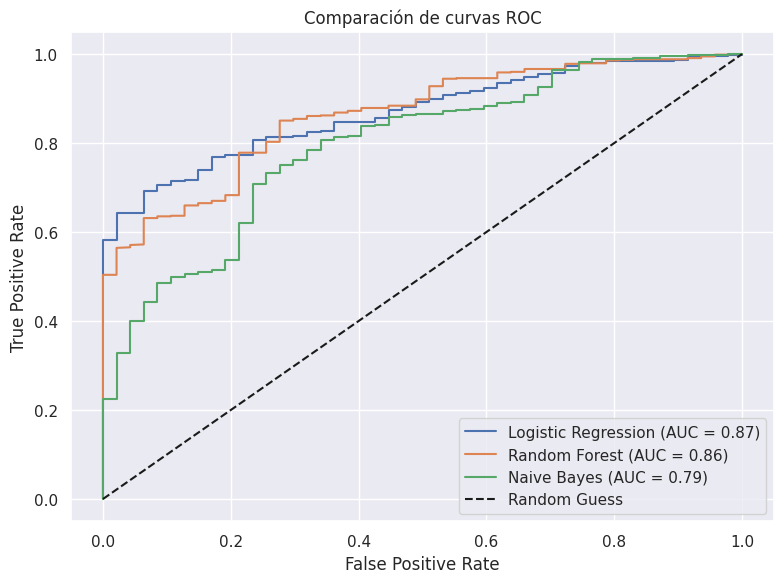

In [289]:
predictions_lr = lr_model.transform(test_df)
predictions_rf = rf_model.transform(test_df)
predictions_nb = nb_model.transform(test_df)

# === Exportar resultados a pandas (solo label y probability) ===
df_lr = predictions_lr.select("label", "probability").toPandas()
df_rf = predictions_rf.select("label", "probability").toPandas()
df_nb = predictions_nb.select("label", "probability").toPandas()

# === Graficar curva ROC comparativa ===
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Etiquetas verdaderas (iguales para todos los modelos)
y_true = df_lr["label"]

# Probabilidades de clase positiva (índice 1 en el vector de probabilidad)
y_scores_lr = df_lr["probability"].apply(lambda x: x[1])
y_scores_rf = df_rf["probability"].apply(lambda x: x[1])
y_scores_nb = df_nb["probability"].apply(lambda x: x[1])

# Calcular FPR, TPR y AUC
fpr_lr, tpr_lr, _ = roc_curve(y_true, y_scores_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_true, y_scores_rf)
fpr_nb, tpr_nb, _ = roc_curve(y_true, y_scores_nb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_nb = auc(fpr_nb, tpr_nb)

# Graficar curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


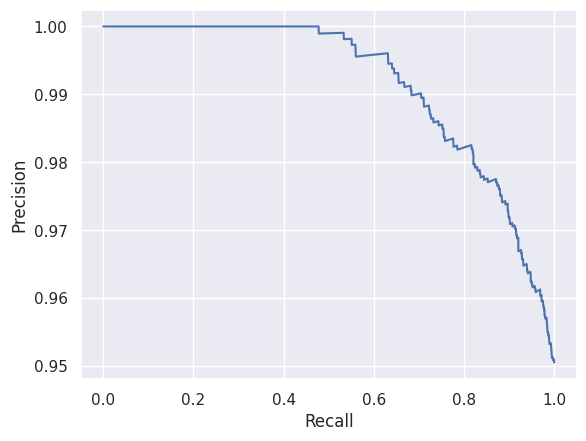

In [279]:
pr = trainingSummary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()

In [290]:
# Se calculan los verdaderos y falsos, tanto positivos como negativos
tp = predictions.filter((predictions['label'] == 1) & (predictions['prediction'] == 1)).count()
fp = predictions.filter((predictions['label'] == 0) & (predictions['prediction'] == 1)).count()
tn = predictions.filter((predictions['label'] == 0) & (predictions['prediction'] == 0)).count()
fn = predictions.filter((predictions['label'] == 1) & (predictions['prediction'] == 0)).count()

# Accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy: {accuracy}")

# Precision
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
print(f"Precision: {precision}")

# Recall
recall = tp / (tp + fn) if (tp + fn) != 0 else 0.0
print(f"Recall: {recall}")

# F1 measure
f1_measure = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0.0
print(f"F1 measure: {f1_measure}")

Accuracy: 0.8250303766707169
Precision: 0.9702380952380952
Recall: 0.8402061855670103
F1 measure: 0.9005524861878453


In [293]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Aplica el modelo al conjunto de prueba
predictions = lr_model.transform(test_df)

# Extrae la probabilidad de la clase positiva (posición 1 del vector)
preds_with_probs = predictions.withColumn("prob_1", vector_to_array("probability")[1])

# Convierte a pandas si necesitas generar el CSV
output_df = preds_with_probs.select("features", "label", "prob_1", "prediction").toPandas()

# Guardar como CSV
output_df.to_csv("predicciones_logistic.csv", index=False)

**Contesta las siguientes preguntas**


1.   ¿Podemos decir que la contaminación por O3 o PM2.5 está ligada al tráfico vehícular?
Debido a que muchas de las variables relacionadas con el tráfico vehícular, como el dióxido de carbono, están altamente correlacionadas con el O3 y las partículas PM2.5, podemos saber que sí están directamente ligadas.
2.   Dado que un reporte del pronóstico del clima dado en la mañana, ¿podemos predecir que habrá una contingenciaambiental debido a que los contaminantes en el aire rebasarán los límites permitidos por la norma?
Sí, podemos predecir que habrá una contingencia cuando muchos de estos contaminantes se encuentran arriba de la norma.
3.   En tus propias palabras, ¿qué condiciones climáticas se deben cumplor para tener altos niveles de contaminación de O3 y PM2.5?
Que haya muy poca humedad relativa, un nivel alto de radiación solar, una temperatura muy alta, que la velocidad del viento sea muy alta.


